# Libraries 

In [218]:
%run ../../../setup_workspace.py # ../ means level up 

from matplotlib.ticker import ScalarFormatter

✓ Workspace ready


In [265]:
scan_session(r"E:\sessions\IHSC_1872")

scan_session(r"E:\sessions\sc5665")

Catalog updated: 336 new experiments added
Catalog updated: 705 new experiments added


# Data

Found 13 EDF files in SAXS
Found 13 EDF files in SAXS
Found 13 EDF files in SAXS


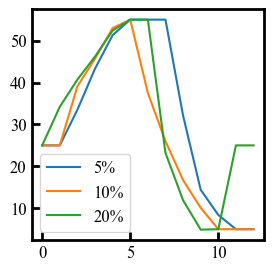

In [224]:
data_5 = BM26_experiment(r"E:\POX_propyl\SC5711\POX_POX_propyl_5perc_RT")
data_10 = BM26_experiment(r"E:\POX_propyl\SC5711\POX_POX_propyl_10perc_RT")
data_20 = BM26_experiment(r"E:\POX_propyl\SC5711\POX_POX_propyl_20perc_RT")
data_100 = BM26_experiment(r"E:\POX_propyl\SC5711\Bottlebrushes_JW_PMOX_PaPrOX")

plt.figure(figsize=(3,3))
plt.plot(data_5.get_T_profile(), label='5%')
plt.plot(data_10.get_T_profile(), label='10%')
plt.plot(data_20.get_T_profile(), label='20%')
plt.legend()

# Functions

In [150]:
from scipy.ndimage import gaussian_filter1d
def smooth_data(q, I, sigma=1.0, method='gaussian'):
    """
    Сглаживание данных для улучшения отображения на логарифмических осях
    
    Parameters:
    -----------
    q : array
        Вектор q-значений
    I : array
        Интенсивность
    sigma : float
        Параметр сглаживания
    method : str
        'gaussian' - гауссовский фильтр
        'savgol' - фильтр Савицкого-Голея
        'spline' - сплайн-интерполяция
    """
    if method == 'gaussian':
        # Гауссовское сглаживание
        I_smooth = gaussian_filter1d(I, sigma=sigma)
        return q, I_smooth
    
    elif method == 'savgol':
        # Фильтр Савицкого-Голея (нужен scipy)
        from scipy.signal import savgol_filter
        window_length = min(51, len(I) // 2 * 2 + 1)  # нечетное число
        I_smooth = savgol_filter(I, window_length, 3)
        return q, I_smooth
    
    elif method == 'spline':
        # Сплайн-интерполяция на логарифмической сетке
        log_q = np.log10(q)
        log_I = np.log10(I)
        
        # Создаем равномерную сетку в логарифмическом пространстве
        q_smooth = np.logspace(np.log10(q.min()), np.log10(q.max()), len(q)*2)
        log_q_smooth = np.log10(q_smooth)
        
        # Интерполируем
        spline = make_interp_spline(log_q, log_I, k=3)
        log_I_smooth = spline(log_q_smooth)
        
        return q_smooth, 10**log_I_smooth
    
    return q, I

def log_normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(np.log(q / q0))**2 / (2 * s**2))

def log_normal_peak_C(q, I0, q0, s, C):
    return I0 * np.exp(-(np.log(q / q0))**2 / (2 * s**2)) + C

def power(q, I_p, p):
    return I_p * q ** -p

def lognorm_power(q, I0, q0, s, I_p, p ):
    return log_normal_peak(q,  I0, q0, s,) +power(q, I_p, p)

# Analysis

In [48]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

(1, 1000.0)

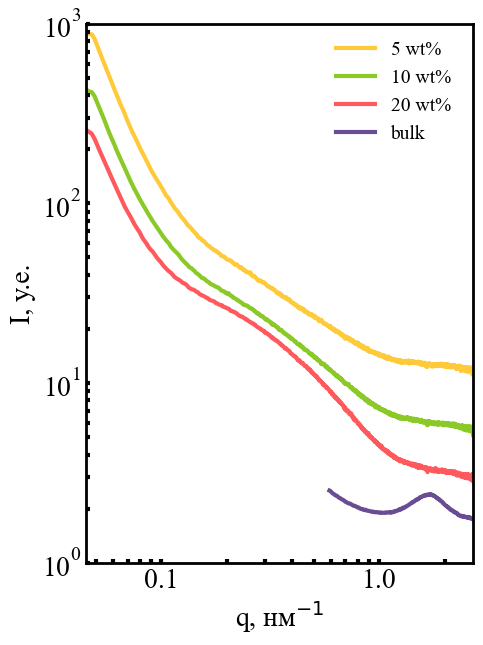

In [274]:
fig, ax = plt.subplots(1,1, figsize=(5,7))

frame = 10
q, I = data_5.get_1d_SAXS(frame)
#q, I = smooth_data(q, I, sigma=3)
#plt.plot(q, I/data_5.get_Tr_profile()[frame], color='black', zorder=10, linewidth=2, dashes=[4, 2])

frame = 6
q, I = data_5.get_1d_SAXS(frame)
#q, I = smooth_data(q, I, sigma=3)
plt.plot(q, I/data_5.get_Tr_profile()[frame] * 8, color='#ffca3a', zorder=0, linewidth=3, label='5 wt%')


frame = 10
q, I = data_10.get_1d_SAXS(frame)
#q, I = smooth_data(q, I, sigma=3)
#plt.plot(q, I/data_10.get_Tr_profile()[frame] * 2, color='black', zorder=10, linewidth=2, dashes=[4, 2])

frame = 6
q, I = data_10.get_1d_SAXS(frame)
#q, I = smooth_data(q, I, sigma=3)
plt.plot(q, I/data_10.get_Tr_profile()[frame] * 4, color='#8ac926', zorder=0, linewidth=3, label='10 wt% ')

frame = 10
q, I = data_20.get_1d_SAXS(frame)
#q, I = smooth_data(q, I, sigma=3)
#plt.plot(q, I/data_20.get_Tr_profile()[frame] * 4, color='black', zorder=10, linewidth=2, dashes=[4, 2])

frame = 6
q, I = data_20.get_1d_SAXS(frame)
#q, I = smooth_data(q, I, sigma=3)
plt.plot(q, I/data_20.get_Tr_profile()[frame] * 2, color='#ff595e', zorder=0, linewidth=3, label='20 wt%')

q, I = data_100.get_1d_SAXS(1)
plt.plot(q[120:-350], I[120:-350] / 16, color='#6a4c93', zorder=0, linewidth=3, label='bulk')


plt.xlabel('q, нм$^{-1}$', fontname='Times New Roman', fontsize=20)  # ← Markdown для степени
plt.ylabel('I, у.е.', fontname='Times New Roman', fontsize=20)

plt.legend(frameon=False, fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks([0.1, 1])
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Устанавливаем Arial для tick labels
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Times New Roman')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Times New Roman')
plt.xlim(0.045, 2.7)
plt.ylim(1, 1e3)

(0.045, 2.7)

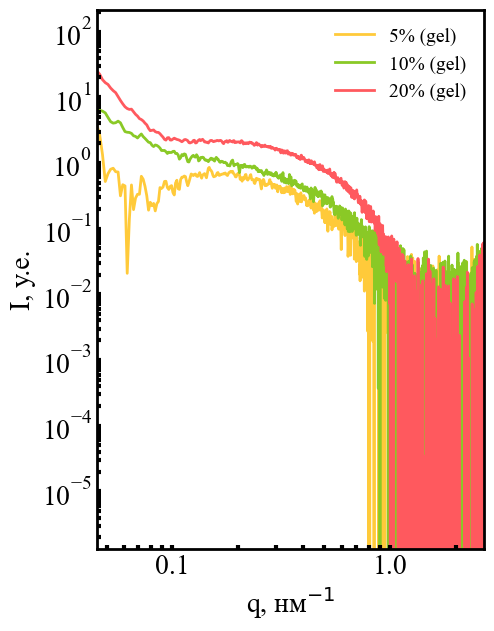

In [264]:
fig, ax = plt.subplots(1,1, figsize=(5,7))

frame = 10
q, I1 = data_5.get_1d_SAXS(frame)
#q, I = smooth_data(q, I, sigma=3)
# plt.plot(q, I1/data_5.get_Tr_profile()[frame], color='black', zorder=10, linewidth=2, dashes=[4, 2])

frame = 6
q, I2 = data_5.get_1d_SAXS(frame)
#q, I = smooth_data(q, I, sigma=3)
plt.plot(q, I1/data_5.get_Tr_profile()[10] - I2/data_5.get_Tr_profile()[6], color='#ffca3a', zorder=0, linewidth=2, label='5% (gel)')


frame = 10
q, I1 = data_10.get_1d_SAXS(frame)
#q, I = smooth_data(q, I, sigma=3)
#plt.plot(q, I1/data_10.get_Tr_profile()[frame] * 2, color='black', zorder=10, linewidth=2, dashes=[4, 2])

frame = 6
q, I2 = data_10.get_1d_SAXS(frame)
#q, I = smooth_data(q, I, sigma=3)
plt.plot(q, I1/data_10.get_Tr_profile()[10] - I2/data_10.get_Tr_profile()[6], color='#8ac926', zorder=0, linewidth=2, label='10% (gel)')

frame = 10
q, I1 = data_20.get_1d_SAXS(frame)
#q, I = smooth_data(q, I, sigma=3)
#plt.plot(q, I1/data_20.get_Tr_profile()[frame] * 4, color='black', zorder=10, linewidth=2, dashes=[4, 2])

frame = 6
q, I2 = data_20.get_1d_SAXS(frame)
#q, I = smooth_data(q, I, sigma=3)
plt.plot(q, I1/data_20.get_Tr_profile()[10] - I2/data_20.get_Tr_profile()[6], color='#ff595e', zorder=0, linewidth=2, label='20% (gel)')


plt.xlabel('q, нм$^{-1}$', fontname='Times New Roman', fontsize=20)  # ← Markdown для степени
plt.ylabel('I, у.е.', fontname='Times New Roman', fontsize=20)

plt.legend(frameon=False, fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')

ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks([0.1, 1])
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Устанавливаем Arial для tick labels
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Times New Roman')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Times New Roman')
plt.xlim(0.045, 2.7)
#plt.ylim(1, 1e3)